STEP 1: LOADING HOUSE PRICE DATASET
✅ Dataset loaded successfully!
📊 Dataset shape: (20640, 10)

First 5 rows:
   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                41.0        880.0           129.0   
1    -122.22     37.86                21.0       7099.0          1106.0   
2    -122.24     37.85                52.0       1467.0           190.0   
3    -122.25     37.85                52.0       1274.0           235.0   
4    -122.25     37.85                52.0       1627.0           280.0   

   population  households  median_income  median_house_value ocean_proximity  
0       322.0       126.0         8.3252            452600.0        NEAR BAY  
1      2401.0      1138.0         8.3014            358500.0        NEAR BAY  
2       496.0       177.0         7.2574            352100.0        NEAR BAY  
3       558.0       219.0         5.6431            341300.0        NEAR BAY  
4       565.0       259.0         3.8462   

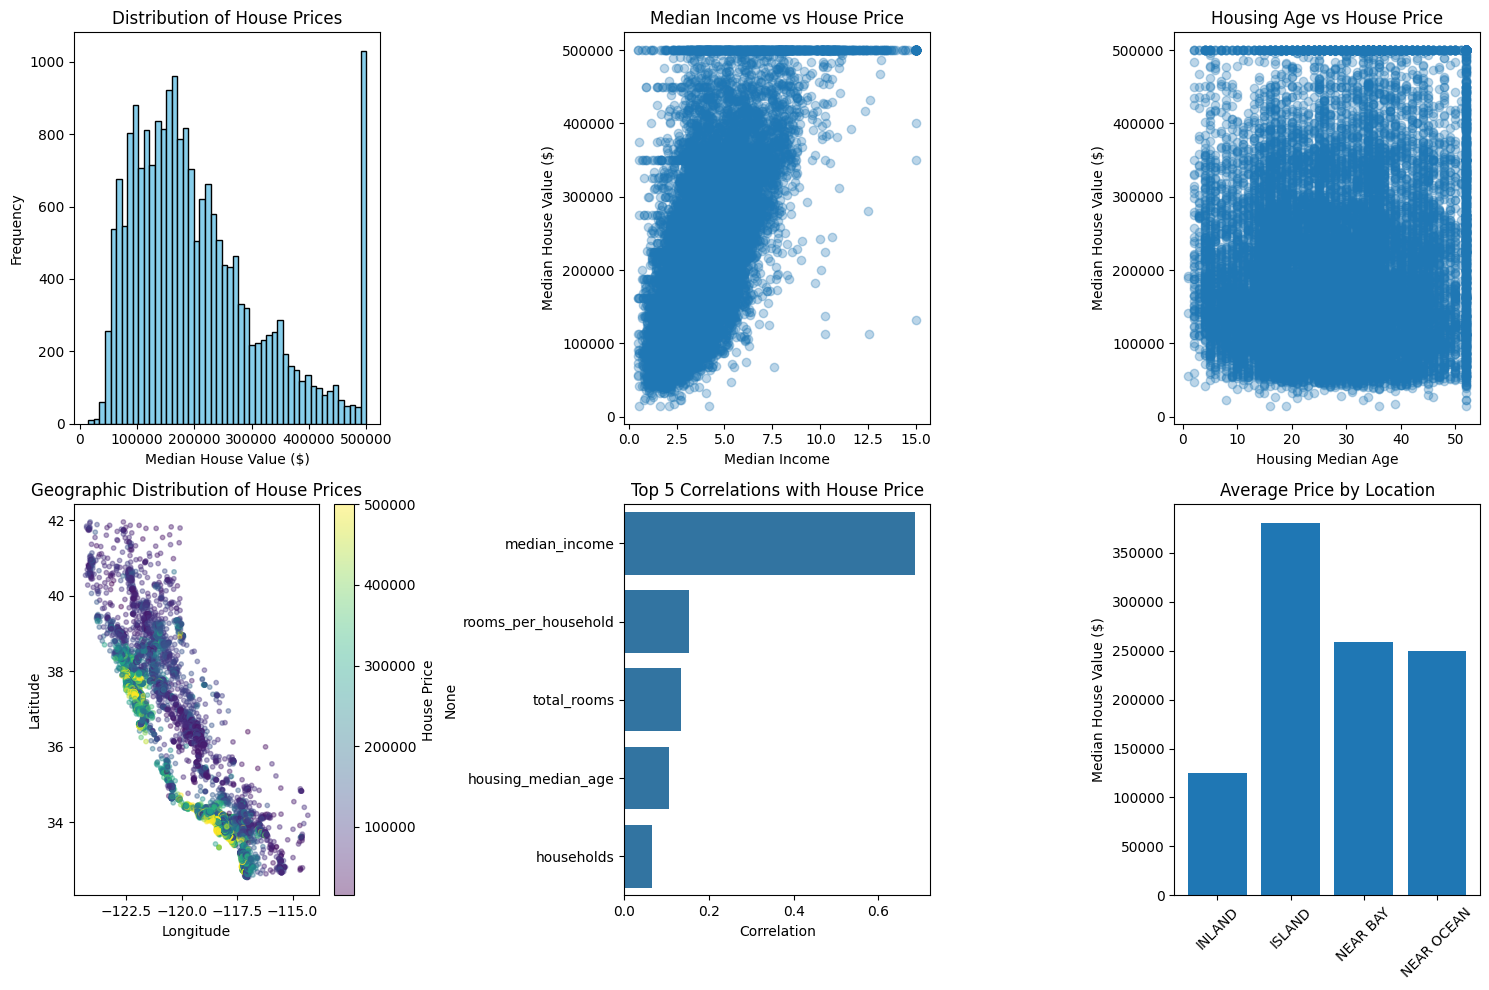


STEP 6: DATA PREPARATION FOR MODELING
Features shape: (20640, 15)
Target shape: (20640,)

Training set size: 16512 samples
Testing set size: 4128 samples
✅ Features scaled using StandardScaler

STEP 7: TRAINING MODELS

Training Linear Regression...
✅ Linear Regression trained

Training Gradient Boosting...
✅ Gradient Boosting trained

STEP 8: MODEL EVALUATION

📊 Linear Regression Performance:
   MAE:  $50,888.66
   RMSE: $72,668.54
   R²:   0.5970

📊 Gradient Boosting Performance:
   MAE:  $32,556.53
   RMSE: $49,085.66
   R²:   0.8161

🏆 Best Model: Gradient Boosting

STEP 9: VISUALIZING PREDICTIONS


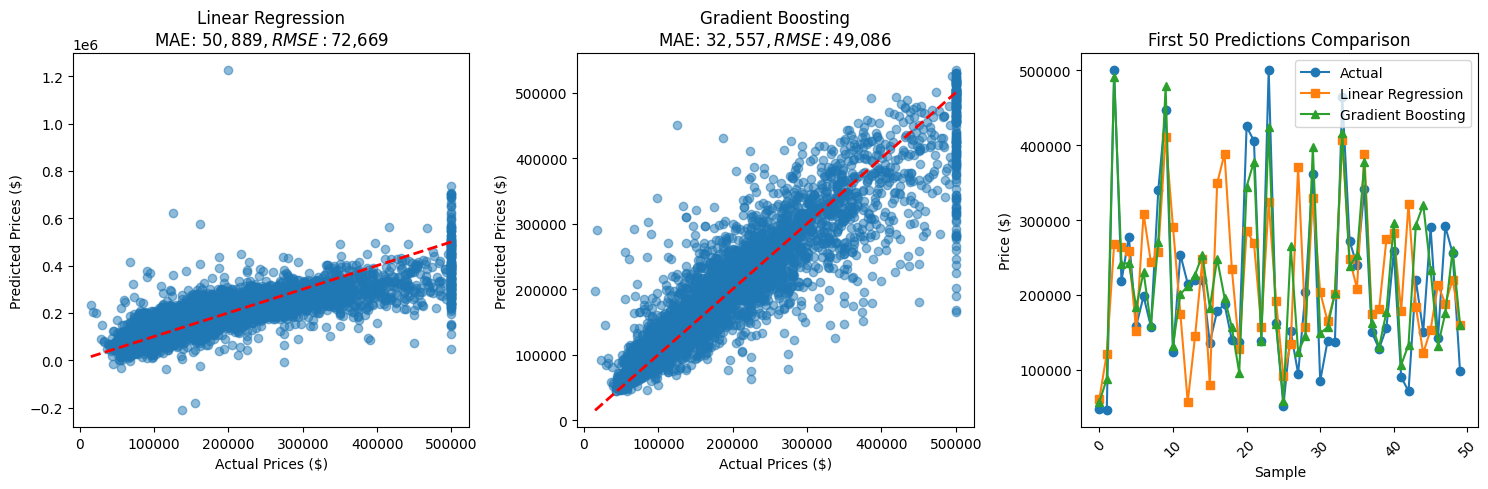


STEP 10: FEATURE IMPORTANCE ANALYSIS

📊 Top 10 Most Important Features:
                 Feature  Importance
           median_income    0.530245
  ocean_proximity_INLAND    0.150216
population_per_household    0.116194
               longitude    0.065169
                latitude    0.061244
      housing_median_age    0.036189
     rooms_per_household    0.012830
       bedrooms_per_room    0.009191
          total_bedrooms    0.004556
             total_rooms    0.004264


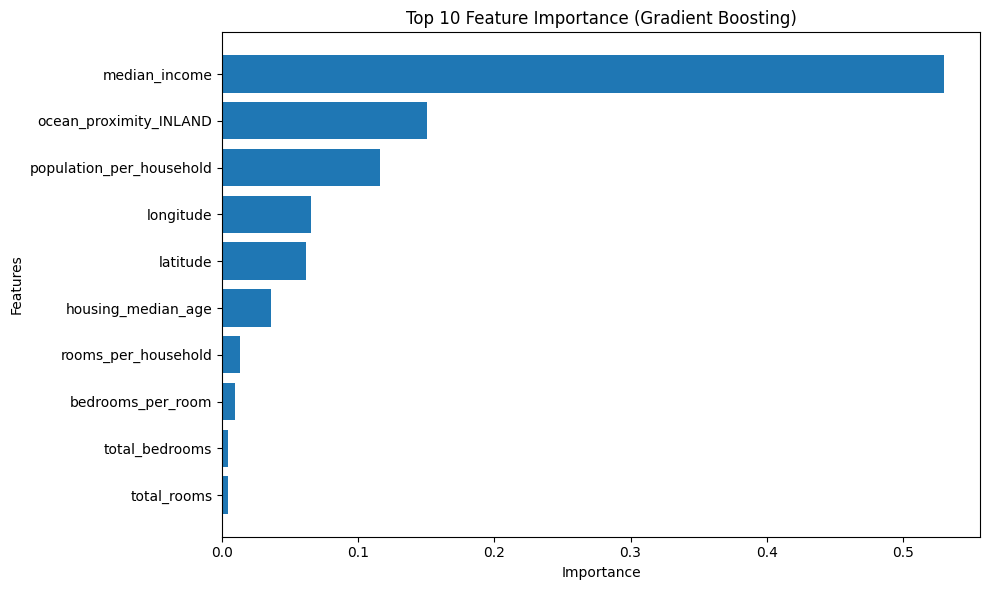


STEP 11: KEY INSIGHTS

🔑 KEY FINDINGS:

1. Most Important Features:
   - median_income: 0.530 importance
   - ocean_proximity_INLAND: 0.150 importance
   - population_per_household: 0.116 importance

2. Model Performance:
   - Best Model: Gradient Boosting
   - MAE: $32,556.53 (average error in prediction)
   - RMSE: $49,085.66 (penalizes larger errors more)

3. Price Range in Dataset:
   - Minimum: $14,999
   - Maximum: $500,001
   - Average: $206,856

4. Key Observations:
   - Median income is strongly correlated with house prices
   - Location (geographic coordinates) significantly impacts prices
   - Property near the ocean tends to have higher values



In [11]:
# Task 6: House Price Prediction
# By : Saif Ullah
# AI/ML Engineering Internship - DevelopersHub Corporation

# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

# ============================================
# STEP 1: LOAD THE DATASET
# ============================================
print("="*60)
print("STEP 1: LOADING HOUSE PRICE DATASET")
print("="*60)

# Load dataset from URL (Kaggle House Price Dataset - simplified version)
# Using a publicly available housing dataset
url = "https://raw.githubusercontent.com/ageron/handson-ml/master/datasets/housing/housing.csv"
df = pd.read_csv(url)

print(f"✅ Dataset loaded successfully!")
print(f"📊 Dataset shape: {df.shape}")
print(f"\nFirst 5 rows:")
print(df.head())

# Display column names
print(f"\n📋 Column Names:")
for i, col in enumerate(df.columns, 1):
    print(f"   {i}. {col}")

# ============================================
# STEP 2: EXPLORE THE DATASET
# ============================================
print("\n" + "="*60)
print("STEP 2: EXPLORING THE DATASET")
print("="*60)

# Basic info
print("\nℹ️ Dataset Info:")
print(df.info())

# Statistical summary
print("\n📊 Statistical Summary:")
print(df.describe())

# Check for missing values
print("\n🔍 Missing Values:")
missing_values = df.isnull().sum()
print(missing_values[missing_values > 0])

# ============================================
# STEP 3: PREPROCESSING
# ============================================
print("\n" + "="*60)
print("STEP 3: PREPROCESSING FEATURES")
print("="*60)

# Handle missing values (fill with median for numerical columns)
print("\nHandling missing values...")
for col in df.columns:
    if df[col].dtype in ['int64', 'float64']:
        df[col].fillna(df[col].median(), inplace=True)

print("✅ Missing values handled")

# Handle categorical variables (one-hot encoding for 'ocean_proximity')
print("\nEncoding categorical variables...")
df = pd.get_dummies(df, columns=['ocean_proximity'], drop_first=True)
print(f"✅ Encoding complete. New shape: {df.shape}")

# Display updated columns
print(f"\nFeatures after preprocessing:")
print(list(df.columns))

# ============================================
# STEP 4: FEATURE ENGINEERING
# ============================================
print("\n" + "="*60)
print("STEP 4: FEATURE ENGINEERING")
print("="*60)

# Create additional features that might help prediction
df['rooms_per_household'] = df['total_rooms'] / df['households']
df['bedrooms_per_room'] = df['total_bedrooms'] / df['total_rooms']
df['population_per_household'] = df['population'] / df['households']

print("✅ Created new features:")
print("   - rooms_per_household")
print("   - bedrooms_per_room")
print("   - population_per_household")

# ============================================
# STEP 5: VISUALIZE DATA
# ============================================
print("\n" + "="*60)
print("STEP 5: DATA VISUALIZATION")
print("="*60)

plt.figure(figsize=(15, 10))

# 5.1 Distribution of house prices
plt.subplot(2, 3, 1)
plt.hist(df['median_house_value'], bins=50, color='skyblue', edgecolor='black')
plt.title('Distribution of House Prices', fontsize=12)
plt.xlabel('Median House Value ($)')
plt.ylabel('Frequency')

# 5.2 Median income vs House price
plt.subplot(2, 3, 2)
plt.scatter(df['median_income'], df['median_house_value'], alpha=0.3)
plt.title('Median Income vs House Price', fontsize=12)
plt.xlabel('Median Income')
plt.ylabel('Median House Value ($)')

# 5.3 Housing age vs House price
plt.subplot(2, 3, 3)
plt.scatter(df['housing_median_age'], df['median_house_value'], alpha=0.3)
plt.title('Housing Age vs House Price', fontsize=12)
plt.xlabel('Housing Median Age')
plt.ylabel('Median House Value ($)')

# 5.4 Geographic distribution
plt.subplot(2, 3, 4)
plt.scatter(df['longitude'], df['latitude'], c=df['median_house_value'],
            cmap='viridis', alpha=0.4, s=10)
plt.colorbar(label='House Price')
plt.title('Geographic Distribution of House Prices', fontsize=12)
plt.xlabel('Longitude')
plt.ylabel('Latitude')

# 5.5 Correlation heatmap
plt.subplot(2, 3, 5)
# Select only numeric columns for correlation
numeric_df = df.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr()
# Get correlations with target
price_corr = corr_matrix['median_house_value'].sort_values(ascending=False)
sns.barplot(x=price_corr.values[1:6], y=price_corr.index[1:6])
plt.title('Top 5 Correlations with House Price', fontsize=12)
plt.xlabel('Correlation')

# 5.6 Box plot for ocean proximity (after encoding)
plt.subplot(2, 3, 6)
# Create a simplified version showing median prices by location
location_cols = [col for col in df.columns if 'ocean_proximity_' in col]
if location_cols:
    location_means = []
    for col in location_cols:
        location_means.append(df[df[col]==1]['median_house_value'].mean())
    plt.bar([col.replace('ocean_proximity_', '') for col in location_cols], location_means)
    plt.title('Average Price by Location', fontsize=12)
    plt.xticks(rotation=45)
    plt.ylabel('Median House Value ($)')

plt.tight_layout()
plt.savefig('house_price_eda.png', dpi=100)
plt.show()

# ============================================
# STEP 6: PREPARE DATA FOR MODELING
# ============================================
print("\n" + "="*60)
print("STEP 6: DATA PREPARATION FOR MODELING")
print("="*60)

# Define features (X) and target (y)
X = df.drop('median_house_value', axis=1)
y = df['median_house_value']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"\nTraining set size: {len(X_train)} samples")
print(f"Testing set size: {len(X_test)} samples")

# Feature scaling (important for Linear Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✅ Features scaled using StandardScaler")

# ============================================
# STEP 7: TRAIN MODELS
# ============================================
print("\n" + "="*60)
print("STEP 7: TRAINING MODELS")
print("="*60)

# 7.1 Linear Regression
print("\nTraining Linear Regression...")
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)
lr_pred = lr_model.predict(X_test_scaled)
print("✅ Linear Regression trained")

# 7.2 Gradient Boosting
print("\nTraining Gradient Boosting...")
gb_model = GradientBoostingRegressor(n_estimators=100, max_depth=5, random_state=42)
gb_model.fit(X_train, y_train)  # Gradient Boosting doesn't need scaled features
gb_pred = gb_model.predict(X_test)
print("✅ Gradient Boosting trained")

# ============================================
# STEP 8: EVALUATE MODELS WITH MAE AND RMSE
# ============================================
print("\n" + "="*60)
print("STEP 8: MODEL EVALUATION")
print("="*60)

# Calculate metrics for Linear Regression
lr_mae = mean_absolute_error(y_test, lr_pred)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
lr_r2 = lr_model.score(X_test_scaled, y_test)

# Calculate metrics for Gradient Boosting
gb_mae = mean_absolute_error(y_test, gb_pred)
gb_rmse = np.sqrt(mean_squared_error(y_test, gb_pred))
gb_r2 = gb_model.score(X_test, y_test)

print("\n📊 Linear Regression Performance:")
print(f"   MAE:  ${lr_mae:,.2f}")
print(f"   RMSE: ${lr_rmse:,.2f}")
print(f"   R²:   {lr_r2:.4f}")

print("\n📊 Gradient Boosting Performance:")
print(f"   MAE:  ${gb_mae:,.2f}")
print(f"   RMSE: ${gb_rmse:,.2f}")
print(f"   R²:   {gb_r2:.4f}")

# Determine best model
best_model = "Gradient Boosting" if gb_rmse < lr_rmse else "Linear Regression"
print(f"\n🏆 Best Model: {best_model}")

# ============================================
# STEP 9: VISUALIZE PREDICTIONS VS ACTUAL
# ============================================
print("\n" + "="*60)
print("STEP 9: VISUALIZING PREDICTIONS")
print("="*60)

plt.figure(figsize=(15, 5))

# 9.1 Linear Regression predictions
plt.subplot(1, 3, 1)
plt.scatter(y_test, lr_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Prices ($)')
plt.ylabel('Predicted Prices ($)')
plt.title(f'Linear Regression\nMAE: ${lr_mae:,.0f}, RMSE: ${lr_rmse:,.0f}')

# 9.2 Gradient Boosting predictions
plt.subplot(1, 3, 2)
plt.scatter(y_test, gb_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Prices ($)')
plt.ylabel('Predicted Prices ($)')
plt.title(f'Gradient Boosting\nMAE: ${gb_mae:,.0f}, RMSE: ${gb_rmse:,.0f}')

# 9.3 Comparison of predictions
plt.subplot(1, 3, 3)
plt.plot(y_test.values[:50], label='Actual', marker='o')
plt.plot(lr_pred[:50], label='Linear Regression', marker='s')
plt.plot(gb_pred[:50], label='Gradient Boosting', marker='^')
plt.xlabel('Sample')
plt.ylabel('Price ($)')
plt.title('First 50 Predictions Comparison')
plt.legend()
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig('house_price_predictions.png', dpi=100)
plt.show()

# ============================================
# STEP 10: FEATURE IMPORTANCE (Gradient Boosting)
# ============================================
print("\n" + "="*60)
print("STEP 10: FEATURE IMPORTANCE ANALYSIS")
print("="*60)

# Get feature importance from Gradient Boosting
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': gb_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\n📊 Top 10 Most Important Features:")
print(feature_importance.head(10).to_string(index=False))

# Plot feature importance
plt.figure(figsize=(10, 6))
plt.barh(feature_importance['Feature'][:10], feature_importance['Importance'][:10])
plt.xlabel('Importance')
plt.ylabel('Features')
plt.title('Top 10 Feature Importance (Gradient Boosting)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('house_price_feature_importance.png', dpi=100)
plt.show()

# ============================================
# STEP 11: FINAL INSIGHTS
# ============================================
print("\n" + "="*60)
print("STEP 11: KEY INSIGHTS")
print("="*60)

print(f"""
🔑 KEY FINDINGS:

1. Most Important Features:
   - {feature_importance.iloc[0, 0]}: {feature_importance.iloc[0, 1]:.3f} importance
   - {feature_importance.iloc[1, 0]}: {feature_importance.iloc[1, 1]:.3f} importance
   - {feature_importance.iloc[2, 0]}: {feature_importance.iloc[2, 1]:.3f} importance

2. Model Performance:
   - Best Model: {best_model}
   - MAE: ${min(lr_mae, gb_mae):,.2f} (average error in prediction)
   - RMSE: ${min(lr_rmse, gb_rmse):,.2f} (penalizes larger errors more)

3. Price Range in Dataset:
   - Minimum: ${y.min():,.0f}
   - Maximum: ${y.max():,.0f}
   - Average: ${y.mean():,.0f}

4. Key Observations:
   - Median income is strongly correlated with house prices
   - Location (geographic coordinates) significantly impacts prices
   - Property near the ocean tends to have higher values
""")